In [2]:
%load_ext autoreload
%autoreload 2

import os
import glob
import sys
sys.path.insert(0, "../")

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# %matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

import warnings
warnings.simplefilter("ignore")

pd.set_option('display.precision', 1)

def load_pyattimo(df_all):
    paths = {
        # "200GB": "../tests/results/pyattimo_0.7.0_200GB",    
        # "20GB": "../tests/results/pyattimo_0.7.0_20GB",
        "pyattimo 8GB" : "../tests/results/pyattimo_0.7.0_8GB",
        "pyattimo 8GB 2" : "../tests/results/pyattimo_converted",
        "attimo" : "../tests/results/attimo_converted"
    }
    
    for name in paths:
        dir_path = paths[name]
        if os.path.isdir(dir_path):
            print(f"Reading from{dir_path}")
            csv_files = glob.glob(os.path.join(dir_path, "*.csv"))
            dfs = [pd.read_csv(file) for file in csv_files]
            
            for key, df in zip(csv_files, dfs):
                filename = os.path.basename(key)
                end = filename.find("pyattimo")                
                if end > 0:
                    df["dataset"] = filename[14:end-4]
                else:   # attimo
                    end = filename.find("attimo")                
                    df["dataset"] = filename[14:end-4]
                
                
            df_config = pd.concat(dfs, ignore_index=True)
            df_config["version"] = name
            df_config["backend"] = name

            # df_config.info()
            
            df_all = pd.concat([df_all, df_config], ignore_index=True)
        else:
            print("Does not exist")

    return df_all


def load_scalable(df_all):
    paths = {
        "scalable_sub": "../tests/results/scalable_sub",    
    }
    
    for name in paths:
        dir_path = paths[name]
        if os.path.isdir(dir_path):
            print(f"Reading from{dir_path}")
            csv_files = glob.glob(os.path.join(dir_path, "*.csv"))
            dfs = [pd.read_csv(file) for file in csv_files]
            
            for key, df in zip(csv_files, dfs):
                factor = key.split("_")[-1][:-4]
                filename = os.path.basename(key)
                end = filename.find("scalable")
                df["dataset"] = filename[14:end-4]            
                df["version"] = "MASS / PAA " + key.split("_")[-1][:-4]
                df["sampling"] = key.split("_")[-1][:-4]
                    
            df_config = pd.concat(dfs, ignore_index=True)
            df_all = pd.concat([df_all, df_config], ignore_index=True)
        else:
            print("Does not exist")

    return df_all

def load_pynndescent(df_all):
    paths = {
        "pynndescent": "../tests/results/pynndescent",    
    }
    
    for name in paths:
        dir_path = paths[name]
        if os.path.isdir(dir_path):
            print(f"Reading from{dir_path}")
            csv_files = glob.glob(os.path.join(dir_path, "*.csv"))
            dfs = [pd.read_csv(file) for file in csv_files]
            
            for key, df in zip(csv_files, dfs):
                filename = os.path.basename(key)
                end = filename.find("pynndescent")
                df["dataset"] = filename[14:end-4]            
                df["version"] = "pynndescent"
            
            df_config = pd.concat(dfs, ignore_index=True)
            df_all = pd.concat([df_all, df_config], ignore_index=True)
        
            # display(df_config)
        else:
            print("Does not exist")
                
    return df_all

def load_faiss(df_all):
    paths = {
        "HNSW": "../tests/results/faiss_HNSW",
        "IVF": "../tests/results/faiss_IVF",
        "LSH": "../tests/results/faiss_LSH_1bit",
        "IVFPQ": "../tests/results/faiss_IVFPQ",
    }
    
    for name in paths:
        dir_path = paths[name]
        if os.path.isdir(dir_path):
            print(f"Reading from{dir_path}")
            csv_files = glob.glob(os.path.join(dir_path, "*.csv"))
            dfs = [pd.read_csv(file) for file in csv_files]
            
            for key, df in zip(csv_files, dfs):
                filename = os.path.basename(key)
                end = filename.find("faiss_backend")
                df["dataset"] = filename[14:end-4]
                # print(filename[14:end-4])
                df["version"] = name
            
            df_config = pd.concat(dfs, ignore_index=True)
            df_all = pd.concat([df_all, df_config], ignore_index=True)
    
            # display(df_config)
        else:
            print("Does not exist")

    return df_all        



def load_latentmotifs(df_all):
    paths = {
        # "latentmotifs_r2": "../tests/results/latentmotifs_r2",
        # "latentmotifs_2r": "../tests/results/latentmotifs_2r",
        "latentmotifs": "../tests/results/latentmotifs_converted",
    }
    
    for name in paths:
        dir_path = paths[name]
        if os.path.isdir(dir_path):
            print(f"Reading from{dir_path}")
            csv_files = glob.glob(os.path.join(dir_path, "*.csv"))
            dfs = [pd.read_csv(file) for file in csv_files]
            
            for key, df in zip(csv_files, dfs):
                filename = os.path.basename(key)
                end = filename.find("latentmotifs")
                df["dataset"] = filename[14:end-4]
                df["version"] = name
                df["backend"] = name
                # print(filename[14:end-4])
                df["extent"] = np.nan
            
            df_config = pd.concat(dfs, ignore_index=True)
            df_all = pd.concat([df_all, df_config], ignore_index=True)
    
            # display(df_config)
        else:
            print("Does not exist")

    return df_all        


def load_momp_conv(df_all):
    paths = {
        "MOMP": "../tests/results/momp_converted2",
    }
    
    for name in paths:
        dir_path = paths[name]
        if os.path.isdir(dir_path):
            print(f"Reading from{dir_path}")
            csv_files = glob.glob(os.path.join(dir_path, "*.csv"))
            dfs = [pd.read_csv(file) for file in csv_files]
            
            for key, df in zip(csv_files, dfs):
                filename = os.path.basename(key)
                df["dataset"] = filename[5:len(filename)-4]
                df["version"] = name
                df["memory in MB"] = np.nan
            
            df_config = pd.concat(dfs, ignore_index=True)
            df_all = pd.concat([df_all, df_config], ignore_index=True)
    
            # display(df_config)
        else:
            print("Does not exist")

    return df_all        


def load_momp(df_all):
    path = "../tests/results/momp/momp.csv"
    print(f"Reading from{path}")
    df = pd.read_csv(path)
    df["version"] = df.backend
    # df["motif length"] = 4096
    df_all = pd.concat([df_all, df], ignore_index=True)
    return df_all

In [3]:
df_all = pd.DataFrame()
df_all = load_pyattimo(df_all)
df_all = load_scalable(df_all)
df_all = load_faiss(df_all)
df_all = load_pynndescent(df_all)
df_all = load_latentmotifs(df_all)
# df_all = load_momp(df_all)
df_all = load_momp_conv(df_all)

# not enough data from all datasets for l=8192
df_all = df_all[df_all["motif length"] <= 4096]
# display(df_all.version.unique())


df_all.loc[df_all.version == "latentmotifs_2r", "version"] = "LM 2"
df_all.loc[df_all.version == "latentmotifs", "version"] = "LM"
# df_all.loc[df_all.version == "pyattimo 8GB", "version"] = "SCAMPI"
df_all.loc[df_all.version == "pyattimo 8GB 2", "version"] = "SCAMPI"
df_all.loc[df_all.version == "attimo", "version"] = "ATTIMO"
df_all.loc[df_all.version == "pyattimo 20GB", "version"] = "SCAMPI (20GB)"
df_all.loc[df_all.version == "pyattimo 200GB", "version"] = "SCAMPI (200GB)"
df_all.loc[df_all.version == "IVFPQ", "version"] = "FAISS (IVFPQ)"
df_all.loc[df_all.version == "HNSW", "version"] = "FAISS (HNSW)"
df_all.loc[df_all.version == "LSH", "version"] = "FAISS (LSH)"
df_all.loc[df_all.version == "IVF", "version"] = "FAISS (IVF)"
df_all.loc[df_all.version == "IVFPQ", "version"] = "FAISS (IVFPQ)"
df_all.loc[df_all.version == "pynndescent", "version"] = "pynndescent"
df_all.loc[df_all.version == "exact (projected)", "version"] = "MASS$^*$"

subset = df_all.loc[df_all.version == "MASS / PAA 16"].copy()
subset.loc[subset.version == "MASS / PAA 16", "time in s"] *= 16**2
subset.loc[subset.version == "MASS / PAA 16", "extent"] *= np.nan
subset.loc[subset.version == "MASS / PAA 16", "memory in MB"] *= np.nan
subset.loc[subset.version == "MASS / PAA 16", "version"] = "Exact$^*$"
subset.loc[subset.version == "MASS / PAA 16", "backend"] = "Exact$^*$"
df_all = pd.concat([df_all, subset], ignore_index=True)

display(df_all.version.unique())

Reading from../tests/results/pyattimo_0.7.0_8GB
Reading from../tests/results/pyattimo_converted
Reading from../tests/results/attimo_converted
Reading from../tests/results/scalable_sub
Reading from../tests/results/faiss_HNSW
Reading from../tests/results/faiss_IVF
Reading from../tests/results/faiss_LSH_1bit
Reading from../tests/results/faiss_IVFPQ
Reading from../tests/results/pynndescent
Reading from../tests/results/latentmotifs_converted
Reading from../tests/results/momp_converted2


array(['pyattimo 8GB', 'SCAMPI', 'ATTIMO', 'MASS / PAA 8',
       'MASS / PAA 32', 'MASS / PAA 64', 'MASS / PAA 16', 'FAISS (HNSW)',
       'FAISS (IVF)', 'FAISS (LSH)', 'FAISS (IVFPQ)', 'pynndescent', 'LM',
       'MOMP', 'Exact$^*$'], dtype=object)

In [4]:
print("Total number of datasets:    ", df_all.dataset.unique().shape[0])

# Filter
counts = df_all.groupby(["dataset", "version"]).size()
counts_df = counts.reset_index(name='count')

display(counts_df[counts_df.version == "ATTIMO"])
count_versions = df_all.version.nunique()

# display("count", count_versions)

# filter datasets where not all indices ran
def all_counts_equal(group):
    return group['version'].nunique() >= count_versions-2 # & (group['count'].min() >= 4)

datasets_to_keep = counts_df.groupby('dataset').filter(all_counts_equal)['dataset'].unique()
print("Filtered number of datasets: ", datasets_to_keep.shape[0])

filtered_df = df_all[df_all["dataset"].isin(datasets_to_keep)]
filtered_df = filtered_df[filtered_df["motif length"] <= 4096]

custom_order = ["SCAMPI", # "SCAMPI CONV", 
                # "ATTIMO",
                "FAISS (IVFPQ)",
                "FAISS (HNSW)",
                "FAISS (LSH)",
                "FAISS (IVF)",
                "FAISS (IVFPQ)",
                "pynndescent",
                "MOMP",
                "LM",
                "LM 2",
                "Exact$^*$"                
               ]

filtered_df = filtered_df[filtered_df.version.isin(custom_order)].copy()
filtered_df = filtered_df[filtered_df.length < 10_000_000]

display(filtered_df.version.unique())

display(filtered_df.dataset.unique())

Total number of datasets:     24


,dataset,version,count
0,Bird12-Week3_2018_1_10,ATTIMO,4
15,BlackLeggedKittiwake,ATTIMO,4
30,Challenge2009Respiration500HZ,ATTIMO,4
59,CinC_Challenge,ATTIMO,4
74,EOG_one_hour_400_Hz,ATTIMO,4
89,EOG_one_hour_50_Hz,ATTIMO,4
104,FingerFlexionECoG,ATTIMO,4
132,Lab_FD_061014,ATTIMO,4
147,Lab_K_060314,ATTIMO,4
162,MGHSleepElectromyography,ATTIMO,4


Filtered number of datasets:  20


array(['SCAMPI', 'FAISS (HNSW)', 'FAISS (IVF)', 'FAISS (LSH)',
       'FAISS (IVFPQ)', 'pynndescent', 'LM', 'MOMP', 'Exact$^*$'],
      dtype=object)

array(['BlackLeggedKittiwake', 'MGHSleepElectromyography', 'swtAttack7',
       'HAR_Ambient_Sensor_Data', 'Lab_FD_061014', 'swtAttack38', 'house',
       'WindTurbine', 'water', 'Challenge2009Respiration500HZ',
       'CinC_Challenge', 'EOG_one_hour_50_Hz', 'solarwind',
       'SpainishEnergyDataset', 'Challenge2009TestSetA_101a',
       'Lab_K_060314', 'stator_winding', 'EOG_one_hour_400_Hz',
       'Bird12-Week3_2018_1_10'], dtype=object)

In [5]:
unique_versions = filtered_df['version'].unique()  # Or your full df if needed
version_order = sorted(unique_versions)  # Or use custom_order
n_versions = len(version_order)
colors = sns.color_palette("husl", n_versions)  # Or "muted", "Set2", etc.

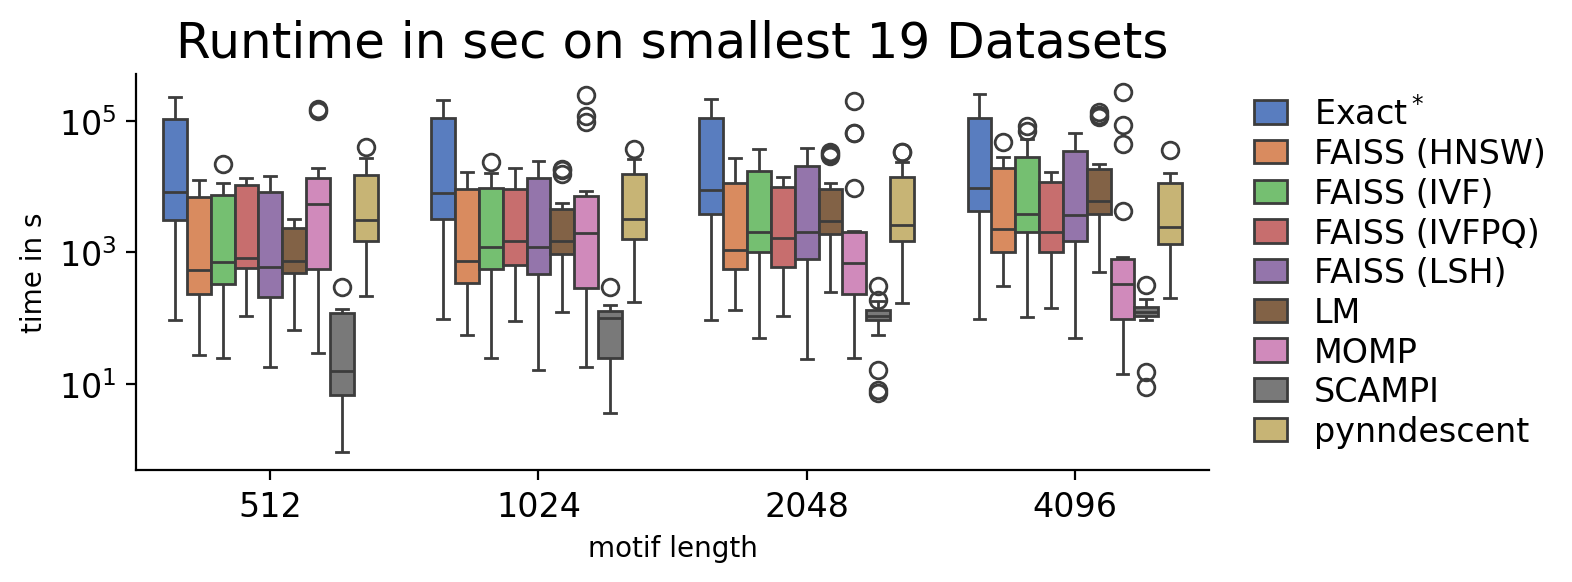

In [6]:
fig, ax = plt.subplots(figsize=(8,3))
ax = sns.boxplot(
    y="time in s", 
    hue="version", 
    x="motif length", 
    data=filtered_df.dropna(subset="time in s"), 
    palette="muted", 
    ax=ax, 
    hue_order=version_order,
    # err_style="bars", 
    # hue_order=custom_order
)
ax.tick_params(axis='both', which='major', labelsize=12)

sns.despine()
plt.tight_layout()
ax.set_title(f"Runtime in sec on smallest {filtered_df.dataset.nunique()} Datasets", fontsize=18)
plt.yscale('log')
# ax.legend(loc='upper center', ncols=5, bbox_to_anchor=(0.5, -0.15))

leg = ax.legend(
    loc="center left",          # anchor legend’s left edge
    bbox_to_anchor=(1.02, 0.5), # (x, y) in axes coords: move right
    fontsize=12,
    handlelength=1.0,
    borderpad=0.2,
    labelspacing=0.2,
    columnspacing=0.5,
    frameon=False,
)

plt.tight_layout()
plt.savefig("images/boxplot_runtime.pdf", bbox_inches='tight')
plt.show()

In [7]:
time = filtered_df.dropna(subset="time in s").groupby("version") \
    .agg({"time in s": ["min","max"]})

# extent["memory in MB"] = memory
display(time)

time in s          
                    min       max
version                          
Exact$^*$          92.9  252372.1
FAISS (HNSW)       27.6   48360.9
FAISS (IVF)        24.8   84600.5
FAISS (IVFPQ)      92.6   19150.3
FAISS (LSH)        16.5   65012.4
LM                 65.5  133762.8
MOMP               14.2  276059.1
SCAMPI              0.9     324.1
pynndescent       170.6   39682.0

In [8]:
time = filtered_df.dropna(subset="time in s").groupby("version") \
    .agg({"time in s":"sum"}).transform(lambda l: l / 3600 ) \
    .rename(columns={"time in s":"time in hours"})

extent = filtered_df.groupby("version") \
    .agg({"extent":["mean", "median"], "memory in MB":["mean", "median"]})

extent["time in hours"] = time

# extent["memory in MB"] = memory
display(extent.sort_values(("extent", "median")))
print(extent.sort_values(("extent", "median")).to_latex(float_format=lambda x: '%.1f' % x))

extent         memory in MB          time in hours
                 mean  median         mean   median              
version                                                          
SCAMPI          288.8    11.8       6958.7   6926.5           2.1
MOMP           1144.4   246.9          NaN      NaN         453.7
pynndescent    2557.0  1714.8     126433.5  80584.2         177.3
FAISS (IVFPQ)  2744.5  1775.1      57288.5  32736.2         108.4
FAISS (HNSW)   2747.9  1806.5      84473.5  47237.6         135.3
FAISS (IVF)    2746.8  1806.5      91238.0  53992.6         208.5
FAISS (LSH)    2782.8  1853.4      57988.1  32942.5         222.4
Exact$^*$         NaN     NaN          NaN      NaN        1338.0
LM                NaN     NaN      53982.0  29059.5         210.7

\begin{tabular}{lrrrrr}
\toprule
 & \multicolumn{2}{r}{extent} & \multicolumn{2}{r}{memory in MB} & time in hours \\
 & mean & median & mean & median &  \\
version &  &  &  &  &  \\
\midrule
SCAMPI & 288.8 & 11.8 & 6958.7 & 6926.5 & 2.1 \\
MOMP & 1144.4 & 246.9 & NaN & NaN & 453.7 \\
pynndescent & 2557.0 & 1714.8 & 126433.5 & 80584.2 & 177.3 \\
FAISS (IVFPQ) & 2744.5 & 1775.1 & 57288.5 & 32736.2 & 108.4 \\
FAISS (HNSW) & 2747.9 & 1806.5 & 84473.5 & 47237.6 & 135.3 \\
FAISS (IVF) & 2746.8 & 1806.5 & 91238.0 & 53992.6 & 208.5 \\
FAISS (LSH) & 2782.8 & 1853.4 & 57988.1 & 32942.5 & 222.4 \\
Exact$^*$ & NaN & NaN & NaN & NaN & 1338.0 \\
LM & NaN & NaN & 53982.0 & 29059.5 & 210.7 \\
\bottomrule
\end{tabular}



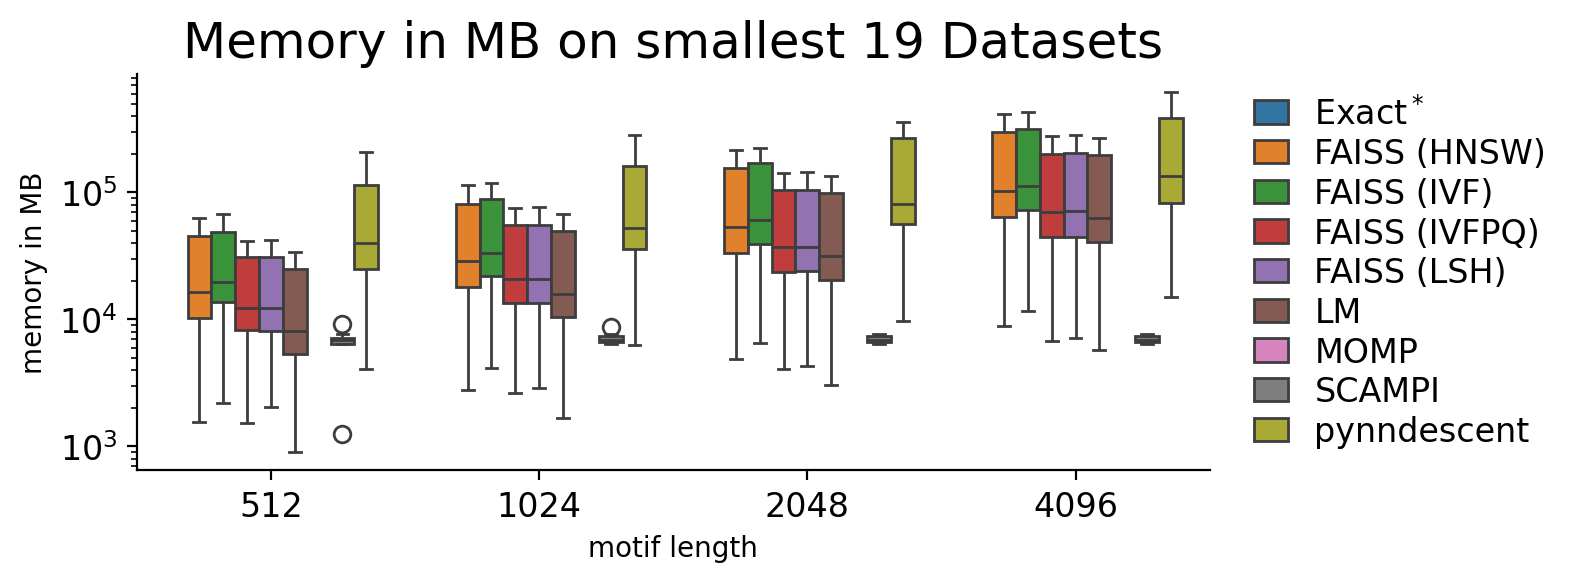

In [9]:
fig, ax = plt.subplots(figsize=(8,3))

ax = sns.boxplot(
    y="memory in MB", 
    hue="version", 
    x="motif length", 
    data=filtered_df.dropna(subset="memory in MB"), 
    hue_order=version_order,    
    # palette="muted", 
    ax=ax,    
    # hue_order=custom_order
)
ax.tick_params(axis='both', which='major', labelsize=12)

sns.despine()
plt.tight_layout()
ax.set_title(f"Memory in MB on smallest {filtered_df.dataset.nunique()} Datasets", fontsize=18)
plt.yscale('log')

leg = ax.legend(
    loc="center left",          # anchor legend’s left edge
    bbox_to_anchor=(1.02, 0.5), # (x, y) in axes coords: move right
    fontsize=12,
    handlelength=1.0,
    borderpad=0.2,
    labelspacing=0.2,
    columnspacing=0.5,
    frameon=False,
)

plt.tight_layout()
plt.savefig("images/boxplot_memory.pdf", bbox_inches='tight')
plt.show()

In [10]:
filtered_df.dropna(subset="memory in MB") \
    .pivot_table(
        values=["memory in MB"], 
        index=["version"], 
        columns=["motif length"], 
        aggfunc='median')

memory in MB                            
motif length          512      1024     2048      4096
version                                               
FAISS (HNSW)       16388.9  28867.7  53533.7  102686.7
FAISS (IVF)        19854.4  33226.0  60713.6  112879.1
FAISS (IVFPQ)      12358.9  20643.0  37115.6   69935.6
FAISS (LSH)        12195.4  20698.4  37427.2   70813.2
LM                  8104.7  15894.5  31418.3   62392.5
SCAMPI              6913.5   6926.5   6926.5    6939.5
pynndescent        39844.9  52784.6  80584.2  135553.3

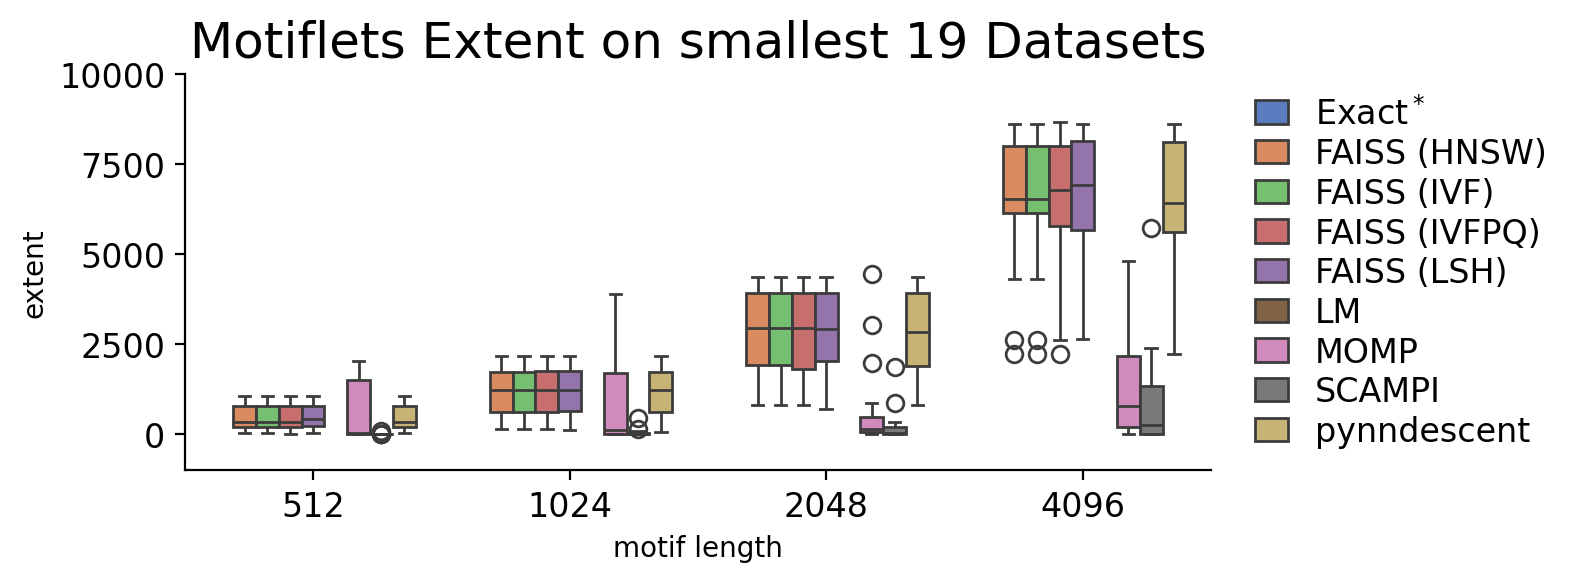

In [11]:
fig, ax = plt.subplots(figsize=(8,3))

ax = sns.boxplot(
    y="extent", 
    hue="version", 
    x="motif length", 
    data=filtered_df.dropna(subset="extent"), 
    palette="muted", 
    ax=ax,
    hue_order=version_order,    
    # hue_order=custom_order
)
ax.tick_params(axis='both', which='major', labelsize=12)

sns.despine()
plt.tight_layout()
ax.set_title(f"Motiflets Extent on smallest {filtered_df.dataset.nunique()} Datasets", fontsize=18)
plt.ylim([-1000, 10000])
# plt.yscale('log')

leg = ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=12,
    handlelength=1.0,
    borderpad=0.2,
    labelspacing=0.2,
    columnspacing=0.5,
    frameon=False,
)

plt.tight_layout()
plt.savefig("images/boxplot_extent.pdf", bbox_inches='tight')
plt.show()

In [12]:
filtered_df.dropna(subset="extent") \
    .pivot_table(
        values=["extent"], 
        index=["version"], 
        columns=["motif length"], 
        aggfunc='mean')

extent                        
motif length    512     1024    2048    4096
version                                     
FAISS (HNSW)   492.4  1175.9  2833.8  6489.6
FAISS (IVF)    489.3  1175.9  2832.4  6489.6
FAISS (IVFPQ)  478.3  1198.8  2821.8  6478.9
FAISS (LSH)    504.9  1197.3  2888.4  6540.5
MOMP           630.0   872.7   699.8  2346.4
SCAMPI           8.5    48.3   219.3   879.2
pynndescent    486.2  1170.8  2800.0  6388.9

In [13]:
# filtered_df.dataset.unique()

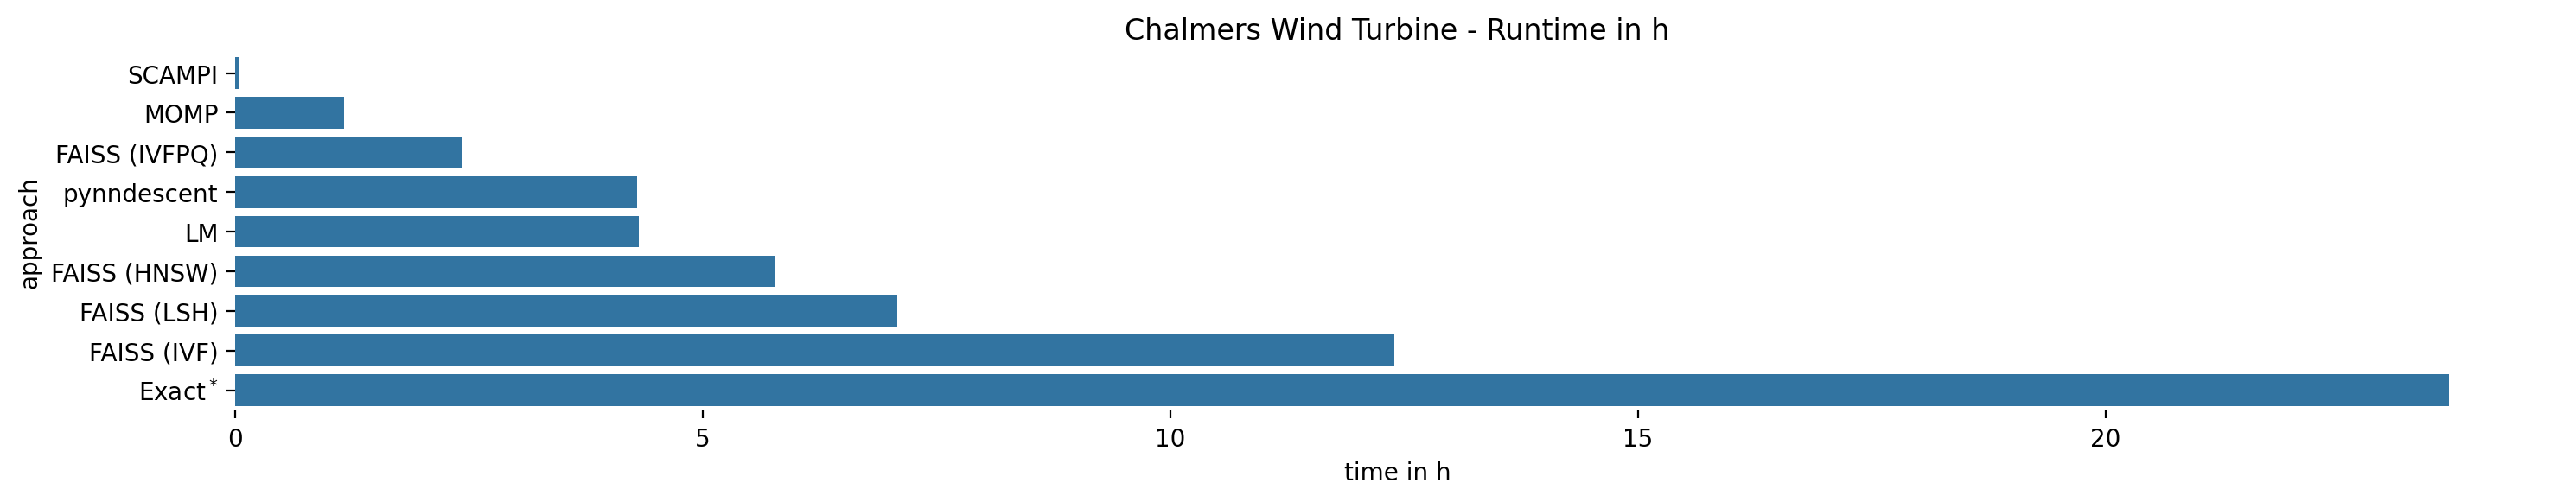

In [14]:
ds = "WindTurbine"
subset = filtered_df[(filtered_df.dataset == ds) & (filtered_df["motif length"]==4096)].dropna(subset="time in s")
subset["time in s"] = subset["time in s"] / 3600
subset = subset.rename(columns={"version" : "approach", "time in s" : "time in h"})
order = subset.groupby("approach").sum().sort_values("time in h").index
plt.subplots(figsize=(15,3))
sns.barplot(y="approach", x="time in h", data=subset, order = order)
sns.despine(top=True, left=True, right=True, bottom=True)

plt.title(f"Chalmers Wind Turbine - Runtime in h")
plt.tight_layout()
plt.savefig("images/windturbine.pdf", bbox_inches='tight')
plt.show()

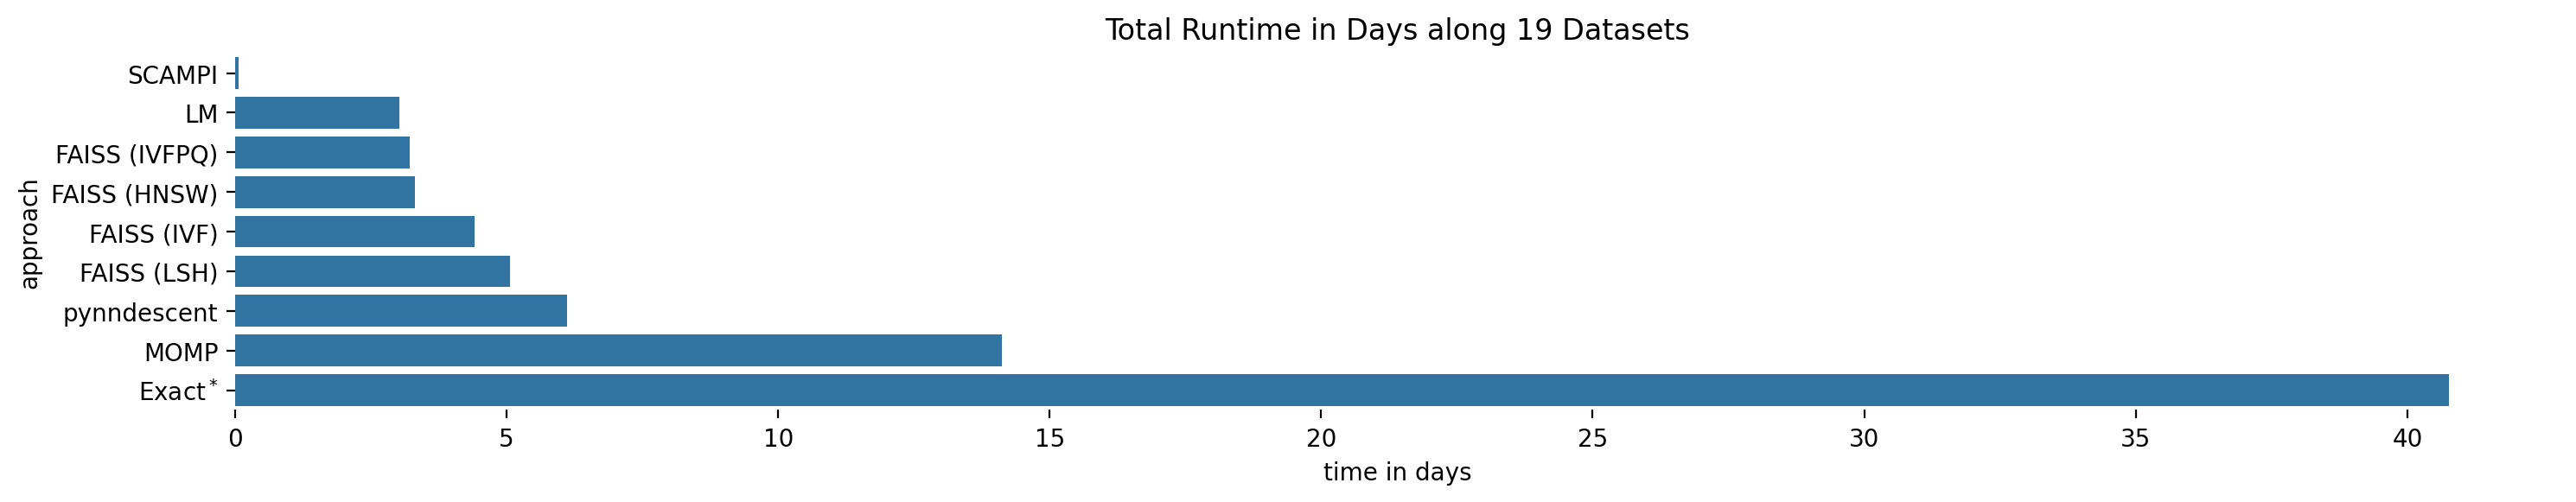

In [15]:
subset = filtered_df.copy().dropna(subset="time in s")
subset = subset[subset["motif length"]<4096]
subset["time in s"] = subset["time in s"] / 3600 / 24
subset = subset.rename(columns={"version" : "approach", "time in s" : "time in days"})
subset = subset.groupby("approach").agg({"time in days":"sum"})
order = subset.sort_values("time in days").index

plt.subplots(figsize=(15,3))
sns.barplot(y="approach", x="time in days", data=subset, order = order)
sns.despine(top=True, left=True, right=True, bottom=True)

# display(subset[["time in days"]])

plt.title(f"Total Runtime in Days along {filtered_df.dataset.nunique()} Datasets")
plt.tight_layout()
plt.savefig("images/all_runtime.pdf", bbox_inches='tight')
plt.show()

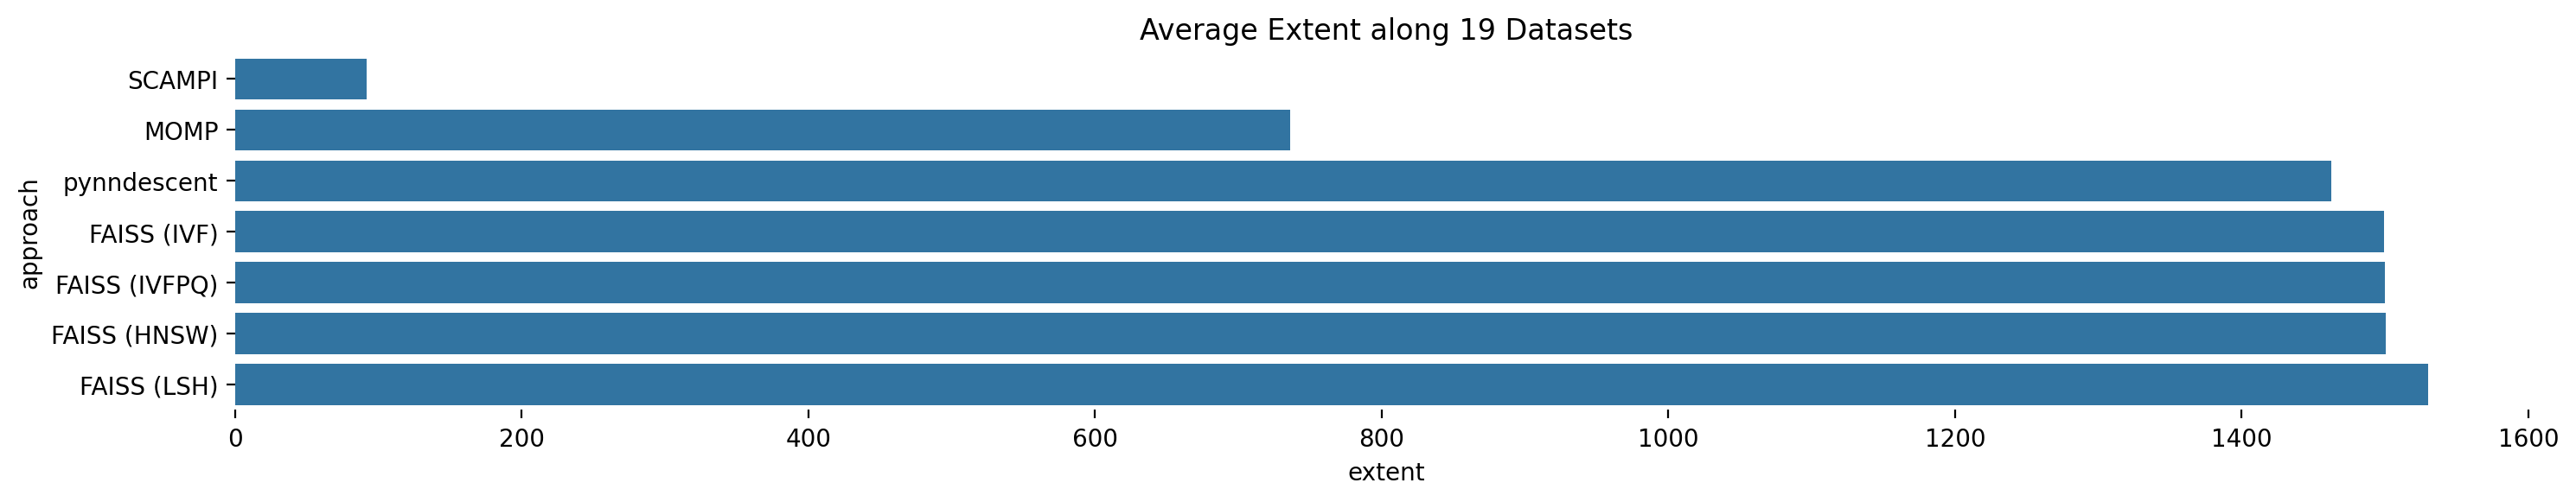

In [16]:
subset = filtered_df.copy().dropna(subset="extent")
subset = subset[subset["motif length"]<4096]
subset["time in s"] = subset["time in s"] / 3600 / 24
subset = subset.rename(columns={"version" : "approach"})
subset = subset.groupby("approach").agg({"extent" : "mean"})
order = subset.sort_values("extent").index

plt.subplots(figsize=(15,3))
sns.barplot(y="approach", x="extent", data=subset, order = order)
sns.despine(top=True, left=True, right=True, bottom=True)

# display(subset[["time in days"]])

plt.title(f"Average Extent along {filtered_df.dataset.nunique()} Datasets")
plt.tight_layout()
plt.savefig("images/all_extent.pdf", bbox_inches='tight')
plt.show()

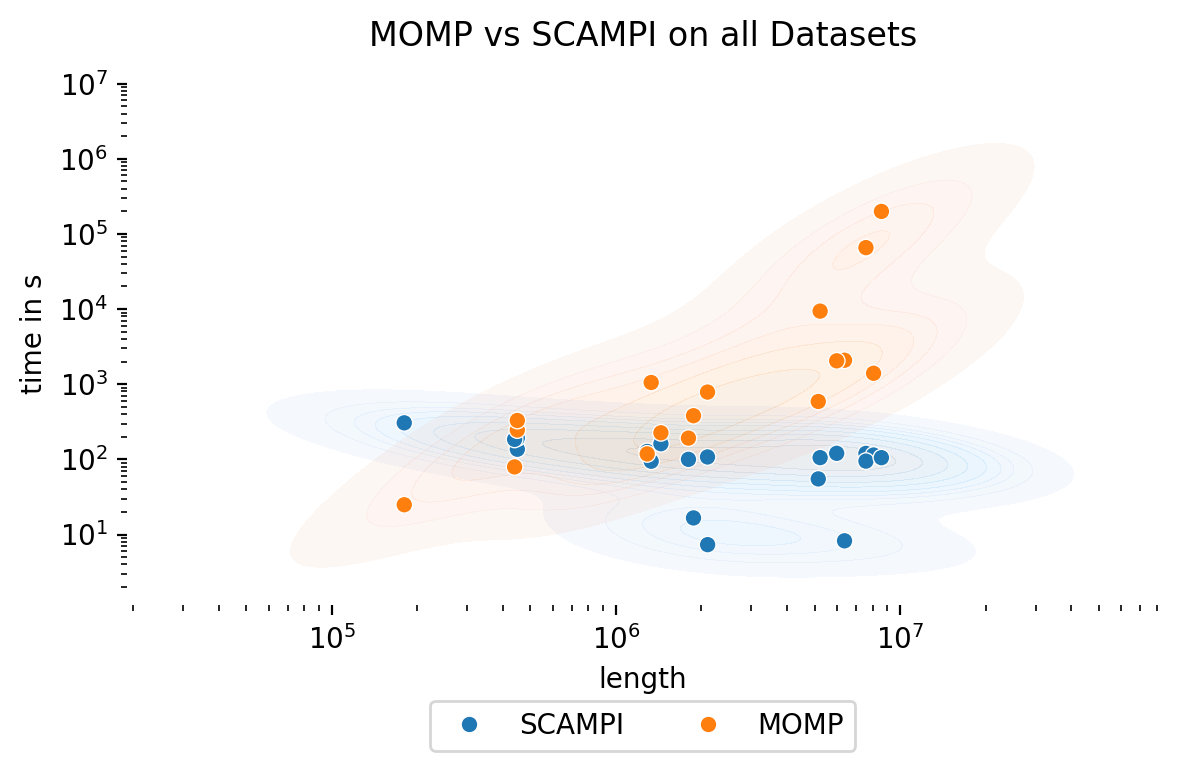

In [17]:
custom_order = ["SCAMPI", "MOMP"]

subset = filtered_df.copy()
subset = subset[(subset["motif length"]==2048)]
subset = subset[subset.version.isin(custom_order)]    

#display(subset)
fig, ax = plt.subplots(figsize=(6,4))
sns.kdeplot(hue="version", x="length", y="time in s", log_scale=True, fill=True, alpha=0.1, data=subset, ax=ax)
sns.scatterplot(hue="version", x="length", y="time in s", data=subset, ax = ax)
sns.despine(top=True, left=True, right=True, bottom=True)

plt.yscale('log')
plt.xscale('log')
plt.legend(loc='upper center', ncols=5, bbox_to_anchor=(0.5, -0.15), ncol=len(custom_order))

plt.title(f"MOMP vs SCAMPI on all Datasets")
plt.tight_layout()
plt.savefig("images/scatter_momp_pimp.pdf")
plt.show()

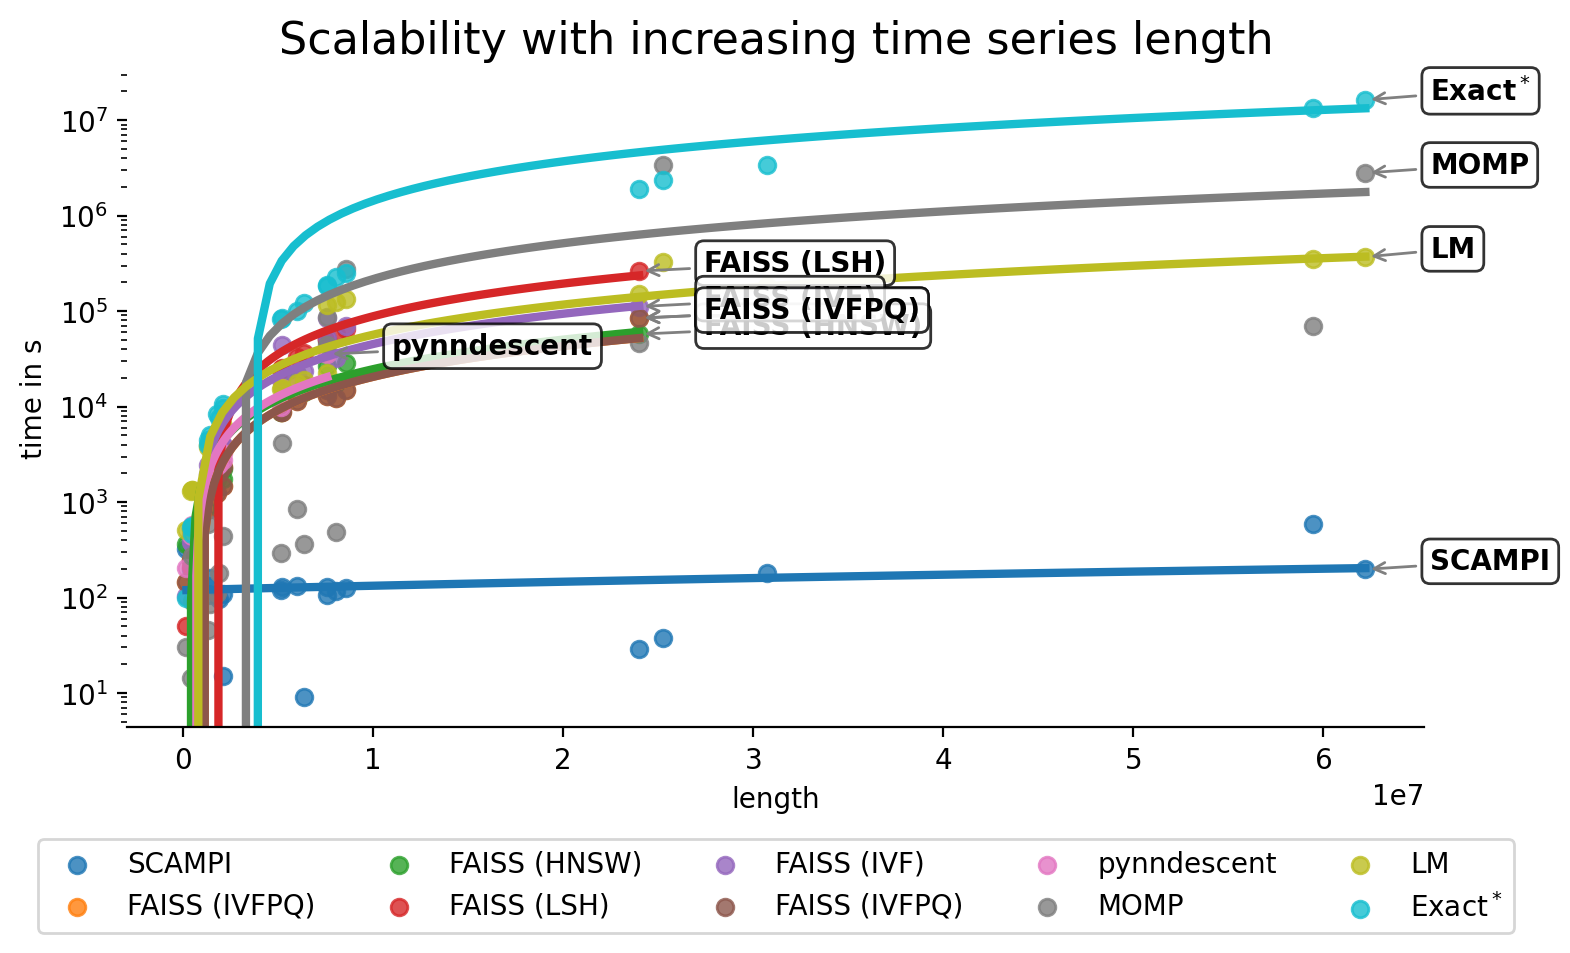

In [25]:
custom_order = ["SCAMPI", 
                "FAISS (IVFPQ)",
                "FAISS (HNSW)",
                "FAISS (LSH)",
                "FAISS (IVF)",
                "FAISS (IVFPQ)",
                "pynndescent",
                "MOMP",
                "LM",
                "Exact$^*$"                
               ]

subset = df_all.copy()
subset = subset[(subset["motif length"]==4096)]
subset = subset[subset.version.isin(custom_order)]    

palette = sns.color_palette("tab10", n_colors=len(custom_order))

#display(subset)
fig, ax = plt.subplots(figsize=(8,5))

for i, order in enumerate(custom_order):
    df_order = subset[subset['version'] == order].convert_dtypes()
    color = palette[i]
    # display(df_order[["length","time in s"]].info())
    sns.regplot(data=df_order, x="length", y="time in s", 
                label=order, 
                ci=0, scatter=True, 
                fit_reg=True, robust=True, truncate=True,
                scatter_kws={'color': color},
                line_kws={'color': color, 'linewidth': 3},                
                ax=ax)


texts = []  # Collect annotations here
for order in custom_order:
    df_order = subset[subset['version'] == order].sort_values('length')
    if not df_order.empty:
        last_point = df_order.iloc[-1]
        x_last, y_last = last_point['length'], last_point['time in s']
        text = ax.annotate(
            order, xy=(x_last, y_last), 
            xytext=(x_last + 0.05 * (ax.get_xlim()[1] - ax.get_xlim()[0]), y_last),
            ha='left', fontsize=10, 
            color='black', weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
            arrowprops=dict(arrowstyle='->', color='gray')
        )
        texts.append(text)


# g = sns.lmplot(hue="version", x="length", y="time in s", data=subset, ci=10, height=6)
sns.despine(top=True, left=True, right=True) # , bottom=True
plt.yscale('log')
# plt.xscale('log')

plt.title(f"Scalability with increasing time series length", fontsize=16)
plt.legend(loc='upper center', ncols=5, bbox_to_anchor=(0.5, -0.15), ncol=len(custom_order))


plt.tight_layout()
plt.savefig("images/scalability.pdf", bbox_inches='tight')
plt.show()

,time in days,extent,speedup
approach,,,
SCAMPI,2.9e-02,249.8,1.0
pynndescent,1.3e+00,6417.8,43.5
FAISS (IVFPQ),2.3e+00,6619.6,77.6
FAISS (HNSW),3.0e+00,6497.1,102.2
MOMP,5.3e+00,808.3,181.7
FAISS (IVF),5.6e+00,6497.1,190.1
FAISS (LSH),7.2e+00,6834.8,247.3
LM,7.5e+00,NaN,256.5
Exact$^*$,3.7e+01,NaN,1260.4


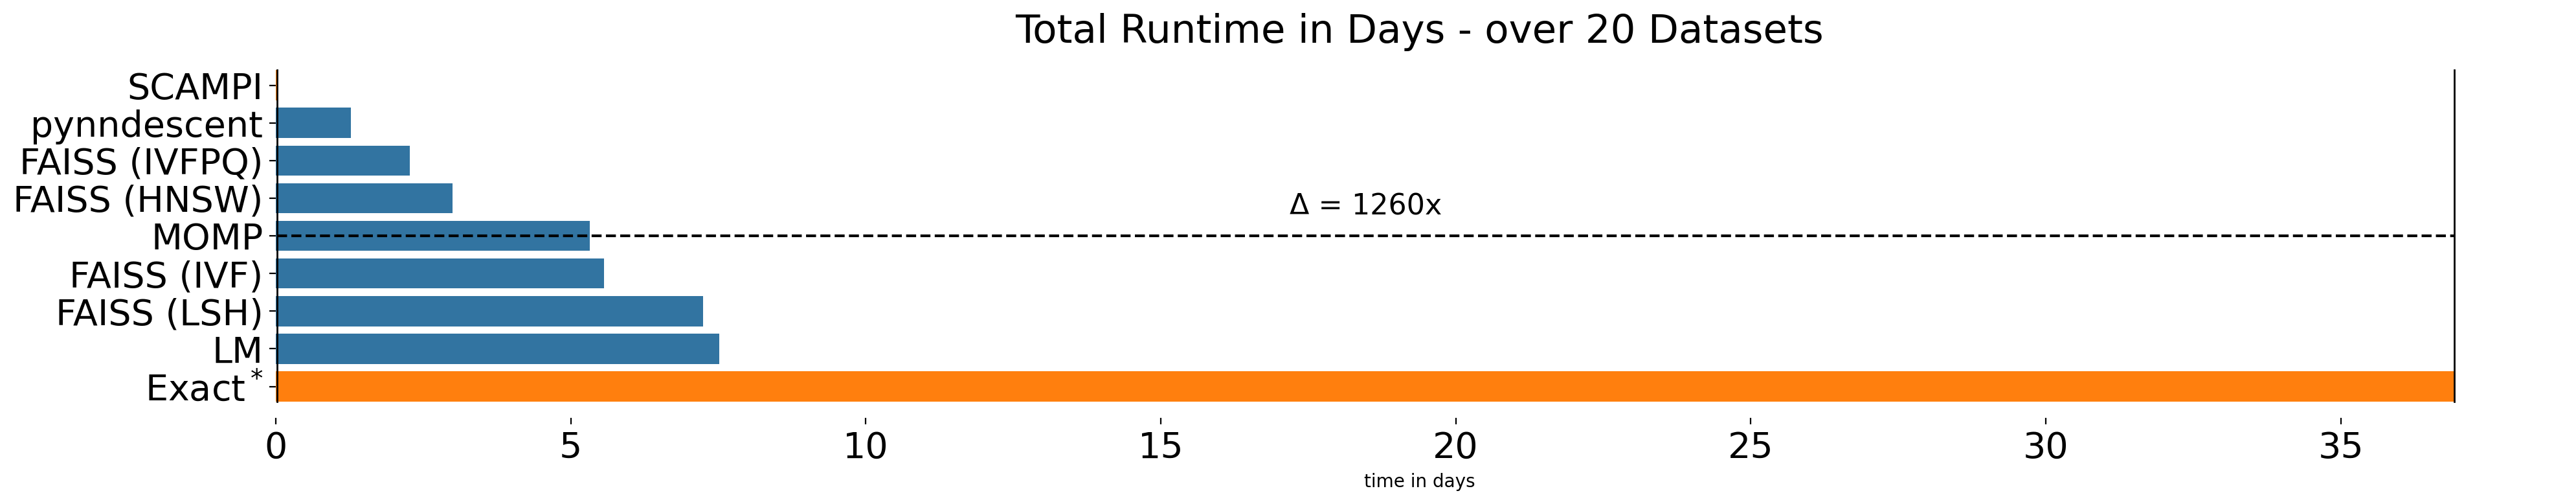

In [26]:
def plot(datasets, length=4096):
    custom_order = ["SCAMPI", 
                    "FAISS (IVFPQ)",
                    "FAISS (HNSW)",
                    "FAISS (LSH)",
                    "FAISS (IVF)",
                    "FAISS (IVFPQ)",
                    "pynndescent",
                    "MOMP",
                    "LM",
                    "Exact$^*$"  
                   ]
    
    filtered_df = df_all[df_all["dataset"].isin(datasets)]
    filtered_df = filtered_df[df_all.version.isin(custom_order)]    
    filtered_df = filtered_df[filtered_df["motif length"] == length]
    
    subset = filtered_df.copy()
    subset["time in s"] = subset["time in s"] / 3600 / 24
    subset = subset.rename(columns={"version" : "approach", "time in s" : "time in days"})
    subset = subset.groupby("approach").agg({"time in days" : "sum", "extent" : "median"})
    order = subset.sort_values("time in days").index
    
    fig, ax = plt.subplots(figsize=(20,4))
    sns.barplot(y="approach", x="time in days", data=subset, order = order, ax = ax)
    sns.despine(top=True, left=True, right=True, bottom=True)
    
    ax = plt.gca() 
    bars = ax.patches
    first_bar = bars[0]
    last_bar = bars[-1]
    first_bar.set_facecolor("#ff7f0e")
    last_bar.set_facecolor("#ff7f0e")
    
    v1 = first_bar.get_width() 
    v2 = last_bar.get_width()
    y_top = last_bar.get_y() + last_bar.get_height()
    y_bottom = first_bar.get_y()
    y_center = (y_top + y_bottom) / 2
    
    ax.plot([v1, v2], [y_center, y_center], color="black", linestyle="--", linewidth=1.5, zorder=3)
    ax.plot([v1, v1], [y_bottom, y_top], color="black", linestyle="-", linewidth=1.0, zorder=3)
    ax.plot([v2, v2], [y_bottom, y_top], color="black", linestyle="-", linewidth=1.0, zorder=3)

    max_d = subset["time in days"].max()
    min_d = subset["time in days"].min()

    speedup = subset.transform (lambda l: l / l.min())
    subset["speedup"] = speedup["time in days"]
    subset = subset.sort_values("time in days", ascending=False)

    display(subset.sort_values("speedup"))
    factor = max_d / min_d
    ax.text((v1 + v2) / 2, y_center-0.4, f"Δ = {factor:.0f}x",
                ha="center", va="bottom", fontsize=16, zorder=4)
    
    n_datasets = filtered_df.dataset.nunique()
    # plt.xscale('log')

    plt.xticks(fontsize=20)
    ax.set_ylabel("")
    plt.yticks(fontsize=20)
    if len(datasets) > 1:
        plt.title(f"Total Runtime in Days - over {n_datasets} Datasets", fontsize=22)
    else: 
        plt.title(f"Runtime in Days - {datasets[0]}", fontsize=22)
    plt.tight_layout()

plot(datasets_to_keep)
plt.savefig("images/runtime_total.pdf", bbox_inches='tight')
plt.show()


In [20]:
#subset.groupby("approach") \
#    .agg({"time in days": "sum"}) \
#    .sort_values("time in days") \
#    .transform(lambda l: l / l.iloc[0]["time in days"]).rename(columns={"time in h":"speedup"})

,time in days,extent,speedup
approach,,,
SCAMPI,3.4e-04,1.1e-03,1.0
MOMP,5.3e-01,8.2e+03,1587.7
FAISS (HNSW),6.6e-01,6.8e+02,1976.0
FAISS (IVFPQ),9.8e-01,2.4e+02,2908.8
FAISS (IVF),1.3e+00,6.8e+02,3837.5
LM,1.8e+00,NaN,5255.5
FAISS (LSH),3.0e+00,8.4e+02,9030.5
Exact$^*$,2.2e+01,NaN,65266.2


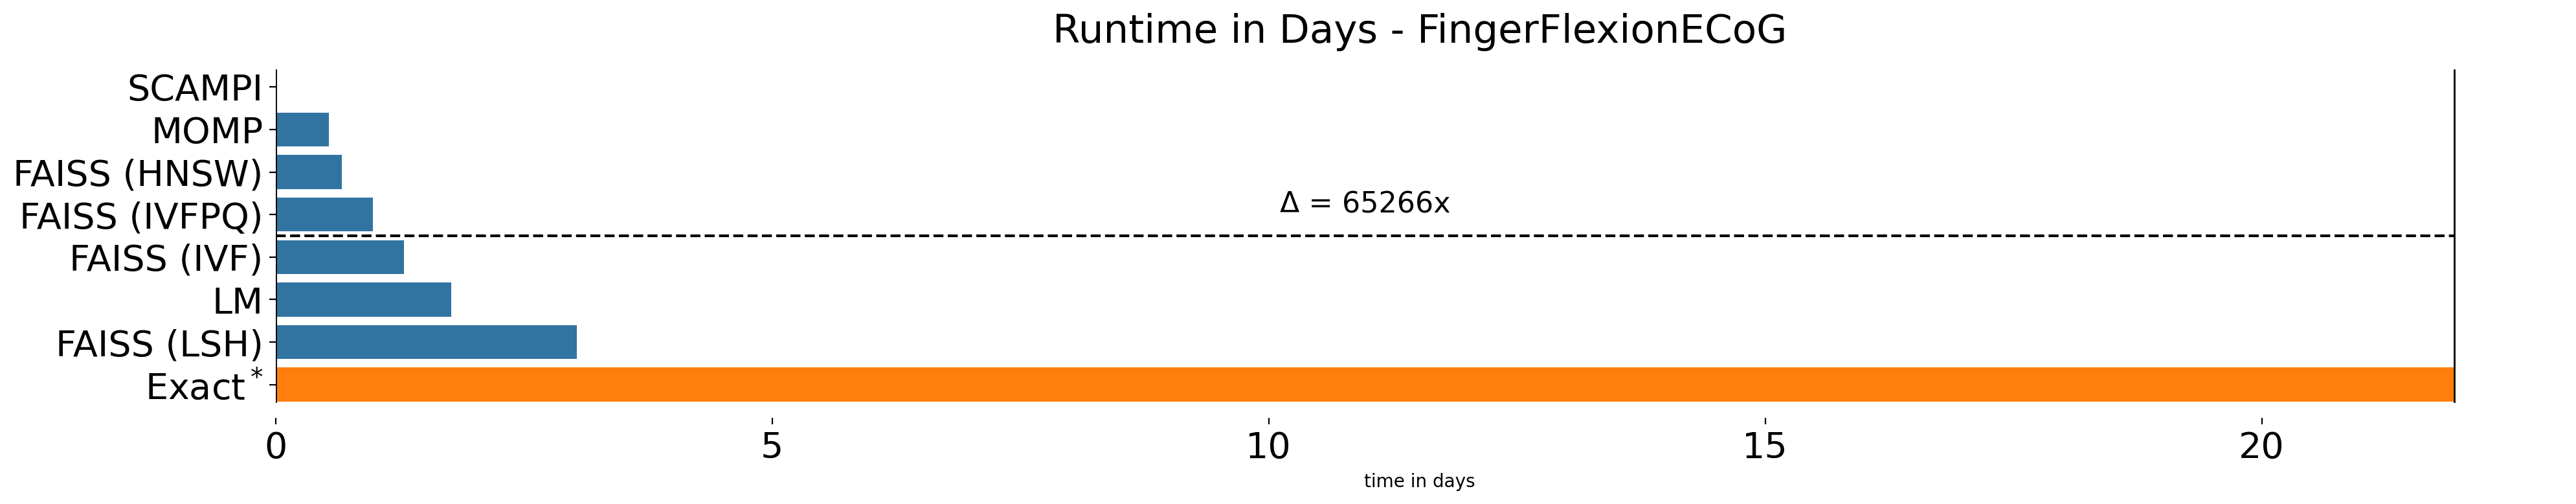

In [21]:
#plot(["WindTurbine"])
#plt.savefig("images/windturbine.pdf")
#plt.show()

plot(["FingerFlexionECoG"])
plt.savefig("images/FingerFlexionECoG.pdf", bbox_inches='tight')
plt.show()


In [22]:
# filtered_df.groupby("dataset").head(1)[["length", "dataset"]].sort_values("length").reset_index(drop=True)

In [23]:
# df_all.groupby("dataset").head(1)[["length", "dataset"]].sort_values("dataset").reset_index(drop=True)

,time in days,extent,speedup
approach,,,
Exact$^*$,2.2e+01,NaN,65266.2
FAISS (LSH),3.0e+00,8.4e+02,9030.5
LM,1.8e+00,NaN,5255.5
FAISS (IVF),1.3e+00,6.8e+02,3837.5
FAISS (IVFPQ),9.8e-01,2.4e+02,2908.8
FAISS (HNSW),6.6e-01,6.8e+02,1976.0
MOMP,5.3e-01,8.2e+03,1587.7
SCAMPI,3.4e-04,1.1e-03,1.0


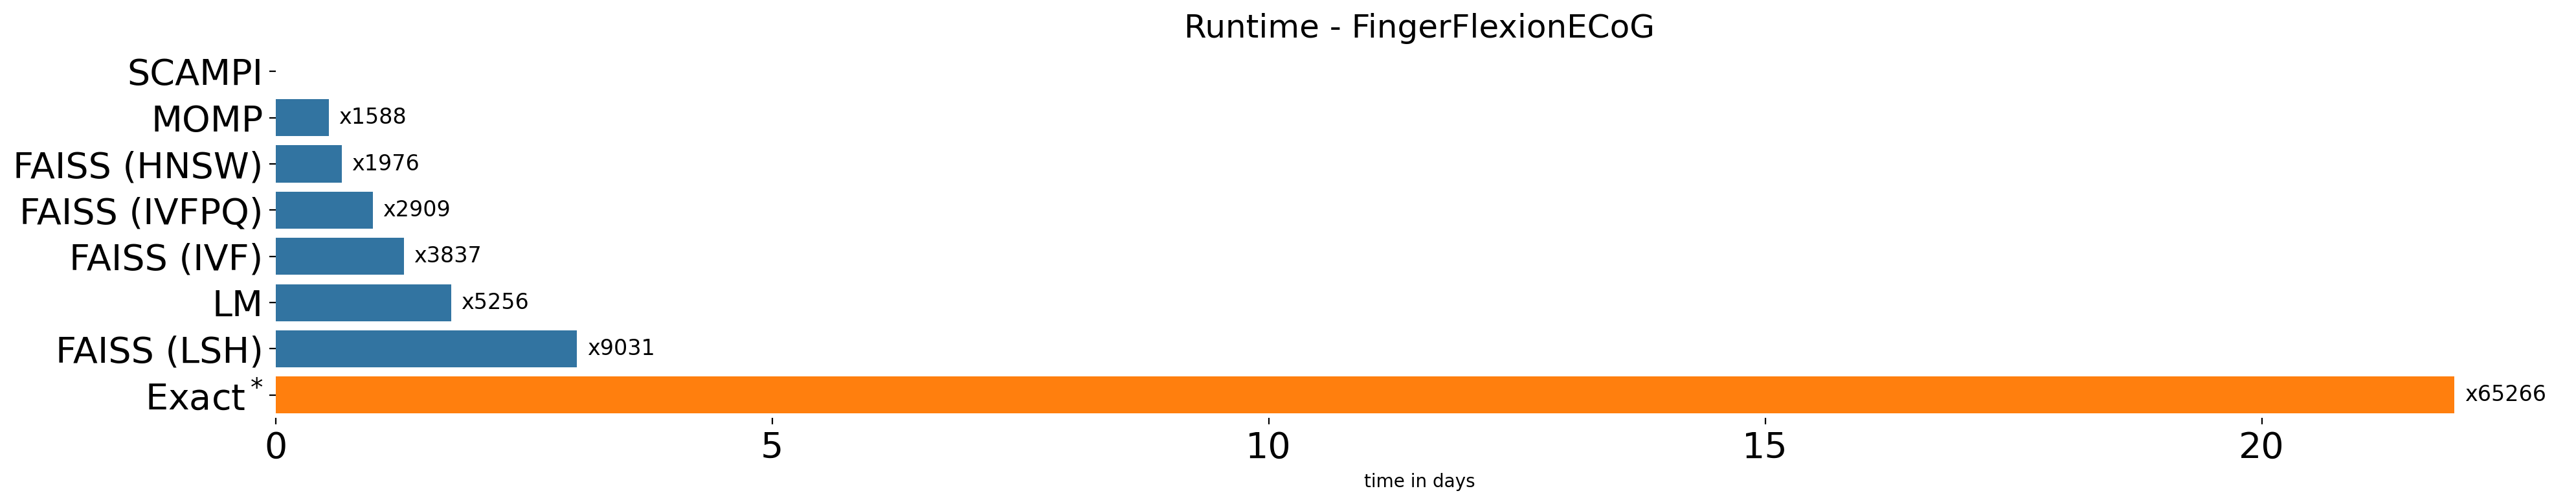

In [24]:
def plot2(datasets, length=4096):
    custom_order = ["SCAMPI",
                    "FAISS (IVFPQ)",
                    "FAISS (HNSW)",
                    "FAISS (LSH)",
                    "FAISS (IVF)",
                    "FAISS (IVFPQ)",
                    "pynndescent",
                    "MOMP",
                    "LM",
                    "Exact$^*$"  
                   ]
    
    filtered_df = df_all[df_all["dataset"].isin(datasets)]
    filtered_df = filtered_df[df_all.version.isin(custom_order)]    
    filtered_df = filtered_df[filtered_df["motif length"] == length]
    
    subset = filtered_df.copy()
    subset["time in s"] = subset["time in s"] / 3600 / 24
    subset = subset.rename(columns={"version" : "approach", "time in s" : "time in days"})
    subset = subset.groupby("approach").agg({"time in days" : "sum", "extent" : "median"})
    order = subset.sort_values("time in days").index

    fig, ax = plt.subplots(figsize=(20,4))
    sns.barplot(y="approach", x="time in days", data=subset, order = order, ax = ax)
    sns.despine(top=True, left=True, right=True, bottom=True)
    
    ax = plt.gca() 
    bars = ax.patches
    first_bar = bars[0]
    last_bar = bars[-1]
    first_bar.set_facecolor("#ff7f0e")
    last_bar.set_facecolor("#ff7f0e")
    
    speedup = subset.transform (lambda l: l / l.min())
    subset["speedup"] = speedup["time in days"]
    subset = subset.sort_values("time in days", ascending=False)

    display(subset)
    
    # Annotate each bar with its speedup value
    for bar, speed in zip(ax.patches[1:], reversed(subset["speedup"].iloc[:-1])):
        width = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        ax.text(
            width + 0.1, y,  # 0.1 units offset right from bar end
            f"x{speed:.0f}",
            va='center', ha='left',
            fontsize=12,
            color='black'
        )
        
    n_datasets = filtered_df.dataset.nunique()

    plt.xticks(fontsize=20)
    ax.set_ylabel("")
    plt.yticks(fontsize=20)
    if len(datasets) > 1:
        plt.title(f"Total Runtime in Days - over {n_datasets} Datasets", fontsize=18)
    else: 
        plt.title(f"Runtime - {datasets[0]}", fontsize=18)
    plt.tight_layout()

plot2(["FingerFlexionECoG"])
plt.savefig("images/FingerFlexionECoG.pdf", bbox_inches='tight')
plt.show()

In [1]:
# df_all[(df_all.version == "Exact$^*$") & (df_all.length > 10**6)].sort_values("length")# ["time in s"] # / 3600 #  / 24